# 02 — Modelo Supervisionado (Score de Recomendação)
**Responsável**: P1 (Presencial)

**Objetivo**: Treinar Random Forest / XGBoost para gerar score de recomendação por artista×país.

**Ordem de execução**: 00 → 01 (clustering, gera `cluster_labels.csv`) → **02 (este notebook)**. Rodar fora dessa ordem quebra o merge da seção 3.

**Guiding Questions**: B (Esse artista vai durar?)

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('../data/processed/artist_country_features.parquet')
cluster_labels = pd.read_csv('../data/processed/cluster_labels.csv')
print(f'Shape features: {df.shape}')
print(f'Shape cluster_labels: {cluster_labels.shape}')

Shape features: (13120, 20)
Shape cluster_labels: (13120, 6)


## 1. Criar Label Sintético (Target)

### Por que a regra original foi trocada

A primeira versão usava `avg_rank ≤ 50` (média do rank diário de TODA a carreira). Isso penalizava exatamente os artistas mais relevantes: `avg_rank` é uma média não ponderada de todo dia de toda faixa, então um artista com catálogo grande (ex. Henrique & Juliano, 212 faixas) acumula muitos dias de faixas de cauda longa em posições baixas, o que arrasta a média pra cima — mesmo dominando `total_streams`. Conferimos com os dados reais do BR: Henrique & Juliano (avg_rank 97,8), Marília Mendonça (86,4) e Ana Castela (79,9) nunca passavam no corte de 50, enquanto artistas com 2-3 faixas que estrearam bem no topo passavam fácil. O resultado final não condizia com a realidade do mercado.

**Regra nova, justa por tamanho de catálogo**: em vez de rank médio absoluto, usamos o **percentil de `total_streams` dentro do próprio país** — isso mede "quão grande é esse artista comparado aos outros do mesmo país", sem punir quem tem catálogo extenso.

- **high**: apareceu nos últimos 90 dias **e** está no top 10% de streams do seu país (`streams_pct ≥ 0.90`)
- **low**: sumiu há mais de 180 dias
- **medium**: demais

Validamos: com essa regra, o top BR agora traz Henrique & Juliano, Marília Mendonça, Gusttavo Lima, Zé Neto & Cristiano, Ana Castela — os nomes que de fato dominam o mercado.

In [13]:
df['streams_pct'] = df.groupby('country')['total_streams'].rank(pct=True)

def create_recommendation_label(row):
    if row['days_since_last_seen'] <= 90 and row['streams_pct'] >= 0.90:
        return 'high'
    elif row['days_since_last_seen'] > 180:
        return 'low'
    else:
        return 'medium'

df['recommend_label'] = df.apply(create_recommendation_label, axis=1)
print('Distribuição do target:')
print(df['recommend_label'].value_counts())
print(df['recommend_label'].value_counts(normalize=True).round(3))

Distribuição do target:
recommend_label
low       10490
medium     1916
high        714
Name: count, dtype: int64
recommend_label
low       0.800
medium    0.146
high      0.054
Name: proportion, dtype: float64


## 2. Diagnosticar o vazamento e preparar features honestas

O F1 = 1.00 vinha de duas coisas ao mesmo tempo:

1. **Vazamento:** `days_since_last_seen` e `avg_rank` definem o label **e** estavam em `X`. `best_rank` e os trends também são proxy de recência (`trend_90d` é NaN exatamente na classe `low`).
2. **`dropna` sumiu com a classe `low`:** 13.220 → ~1.440 linhas, só `high` vs `medium`. Aí a regra fica ainda mais trivial.

Correção: tirar do modelo qualquer coluna usada na regra (ou que a reproduza), imputar ouvintes em vez de dropar linha, regularizar a floresta e comparar treino vs teste vs CV.

In [14]:
# Colunas que definem o label (ou o reproduzem) — fora do modelo
leaked_cols = ['days_since_last_seen', 'avg_rank', 'best_rank', 'trend_30d', 'trend_90d']
print(f'Fora do modelo (vazamento/recência): {leaked_cols}')

Fora do modelo (vazamento/recência): ['days_since_last_seen', 'avg_rank', 'best_rank', 'trend_30d', 'trend_90d']


## 3. Correções nas colunas selecionadas

Quatro problemas encontrados na primeira versão do notebook, todos corrigidos aqui:

1. **`avg_rank` penalizava catálogo grande** — corrigido trocando o critério de `high` por percentil de `total_streams` dentro do país (seção 1 acima).
2. **Artistas duplicados por `artist_uri`.** Descobrimos que o mesmo artista às vezes tem mais de um perfil no Spotify (ex. "Henrique & Juliano" tinha um perfil de 212 faixas e outro quase morto de 2 faixas) — isso fragmentava o sinal do artista principal. Corrigido no [00_data_loading.ipynb](00_data_loading.ipynb) (seção 5.1): consolidamos por `(artist_name, país)`, 99 grupos de duplicatas viraram 99 linhas únicas. `df` já vem deduplicado do parquet.
3. **`monthly_listeners`/`peak_listeners` são globais, não por país.** Vêm de `artists.csv`, join só por `artist_uri` — um artista presente em vários países da base recebe o **mesmo** valor em cada linha de país, mesmo tendo relevância bem diferente em cada um. Correção: `country_stream_share` = fração do streaming total do artista (nos 5 países da base) que veio deste país específico — sinal genuinamente por país.
4. **25,4% de nulos** em `monthly_listeners`/`peak_listeners`/`listener_ratio`, antes preenchidos cegamente com a mediana. Correção: `SimpleImputer(add_indicator=True)` — o modelo passa a enxergar *que* o dado faltava, em vez de um valor "médio" disfarçado de real.

Além disso, mantemos o **perfil de carreira** (Veterano Consistente / Consolidado / Nicho Recorrente / One-Hit Wonder / Efêmero Cauda Longa / Legado Global) do notebook 01 como feature one-hot — construído sem `trend`/`rank`/recência, então seguro para entrar aqui sem vazar o target.

In [15]:
df_model = df.merge(cluster_labels[['artist_uri', 'country', 'profile', 'trend_status']], on=['artist_uri', 'country'], how='left')
print('Linhas sem profile após merge:', df_model['profile'].isnull().sum())

# country_stream_share: quanto do streaming total do artista (nos 5 países da base) veio deste país
artist_total = df_model.groupby('artist_uri')['total_streams'].transform('sum')
df_model['country_stream_share'] = df_model['total_streams'] / artist_total

profile_dummies = pd.get_dummies(df_model['profile'].str.replace(' ', '_'), prefix='profile')
df_model = pd.concat([df_model, profile_dummies], axis=1)

numeric_impute_cols = ['monthly_listeners', 'peak_listeners', 'listener_ratio']
numeric_passthrough_cols = ['total_tracks', 'total_streams', 'days_on_chart_total',
                             'stream_concentration', 'entry_count', 'country_stream_share']
profile_cols = profile_dummies.columns.tolist()
feature_cols = numeric_impute_cols + numeric_passthrough_cols + profile_cols

print(f'\nFeatures no modelo ({len(feature_cols)}): {feature_cols}')

X = df_model[feature_cols]
y = df_model['recommend_label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'\nClasses: {list(le.classes_)}')
print(f'Linhas para modelagem: {len(df_model)} / {len(df)}')

Linhas sem profile após merge: 0

Features no modelo (15): ['monthly_listeners', 'peak_listeners', 'listener_ratio', 'total_tracks', 'total_streams', 'days_on_chart_total', 'stream_concentration', 'entry_count', 'country_stream_share', 'profile_Consolidado', 'profile_Efemero_Cauda_Longa', 'profile_Legado_Global', 'profile_Nicho_Recorrente', 'profile_One-Hit_Wonder', 'profile_Veterano_Consistente']

Classes: ['high', 'low', 'medium']
Linhas para modelagem: 13120 / 13120


## 4. Train/Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('Treino:', dict(zip(le.classes_, np.bincount(y_train))))
print('Teste :', dict(zip(le.classes_, np.bincount(y_test))))

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('impute', SimpleImputer(strategy='median', add_indicator=True), numeric_impute_cols),
        ],
        remainder='passthrough',
    )

# Árvore não precisa de StandardScaler.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train: (10496, 15), Test: (2624, 15)
Treino: {'high': np.int64(571), 'low': np.int64(8392), 'medium': np.int64(1533)}
Teste : {'high': np.int64(143), 'low': np.int64(2098), 'medium': np.int64(383)}


## 5. Random Forest (regularizado)

`max_depth`, `min_samples_leaf` e `min_samples_split` limitam árvores que decoram as 67 linhas `high`. O relatório de **treino e teste** tem que ficar parecido; se o treino for 1.00 e o teste cair, aí sim é overfit.

In [17]:
pipe_rf = Pipeline([
    ('prep', make_preprocessor()),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=20,
        min_samples_split=40,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    )),
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
y_pred_rf_train = pipe_rf.predict(X_train)

print('=== Random Forest — TREINO ===')
print(classification_report(y_train, y_pred_rf_train, target_names=le.classes_))
print('=== Random Forest — TESTE ===')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
print(f'F1 weighted  treino: {f1_score(y_train, y_pred_rf_train, average="weighted"):.4f}')
print(f'F1 weighted  teste : {f1_score(y_test, y_pred_rf, average="weighted"):.4f}')
print(f'F1 macro     treino: {f1_score(y_train, y_pred_rf_train, average="macro"):.4f}')
print(f'F1 macro     teste : {f1_score(y_test, y_pred_rf, average="macro"):.4f}')

cv_rf = cross_val_score(pipe_rf, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'CV 5-fold F1 macro: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')

=== Random Forest — TREINO ===
              precision    recall  f1-score   support

        high       0.52      0.97      0.68       571
         low       0.94      0.66      0.77      8392
      medium       0.29      0.66      0.40      1533

    accuracy                           0.68     10496
   macro avg       0.58      0.76      0.62     10496
weighted avg       0.82      0.68      0.71     10496

=== Random Forest — TESTE ===
              precision    recall  f1-score   support

        high       0.45      0.97      0.61       143
         low       0.93      0.65      0.76      2098
      medium       0.27      0.60      0.37       383

    accuracy                           0.66      2624
   macro avg       0.55      0.74      0.58      2624
weighted avg       0.80      0.66      0.70      2624

F1 weighted  treino: 0.7135
F1 weighted  teste : 0.6965
F1 macro     treino: 0.6165
F1 macro     teste : 0.5824
CV 5-fold F1 macro: 0.6035 ± 0.0104


## 6. XGBoost

In [18]:
sw = compute_sample_weight('balanced', y_train)
pipe_xgb = Pipeline([
    ('prep', make_preprocessor()),
    ('clf', xgb.XGBClassifier(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_weight=8,
        reg_lambda=2.0,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss',
    )),
])
pipe_xgb.fit(X_train, y_train, clf__sample_weight=sw)
y_pred_xgb = pipe_xgb.predict(X_test)
y_pred_xgb_train = pipe_xgb.predict(X_train)

print('=== XGBoost — TREINO ===')
print(classification_report(y_train, y_pred_xgb_train, target_names=le.classes_))
print('=== XGBoost — TESTE ===')
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))
print(f'F1 weighted  treino: {f1_score(y_train, y_pred_xgb_train, average="weighted"):.4f}')
print(f'F1 weighted  teste : {f1_score(y_test, y_pred_xgb, average="weighted"):.4f}')
print(f'F1 macro     treino: {f1_score(y_train, y_pred_xgb_train, average="macro"):.4f}')
print(f'F1 macro     teste : {f1_score(y_test, y_pred_xgb, average="macro"):.4f}')

=== XGBoost — TREINO ===
              precision    recall  f1-score   support

        high       0.54      0.97      0.69       571
         low       0.94      0.73      0.82      8392
      medium       0.34      0.65      0.45      1533

    accuracy                           0.73     10496
   macro avg       0.61      0.78      0.65     10496
weighted avg       0.83      0.73      0.76     10496

=== XGBoost — TESTE ===
              precision    recall  f1-score   support

        high       0.47      0.96      0.63       143
         low       0.93      0.71      0.81      2098
      medium       0.31      0.60      0.41       383

    accuracy                           0.71      2624
   macro avg       0.57      0.76      0.62      2624
weighted avg       0.82      0.71      0.74      2624

F1 weighted  treino: 0.7604
F1 weighted  teste : 0.7383
F1 macro     treino: 0.6540
F1 macro     teste : 0.6156


## 7. Confusion Matrix

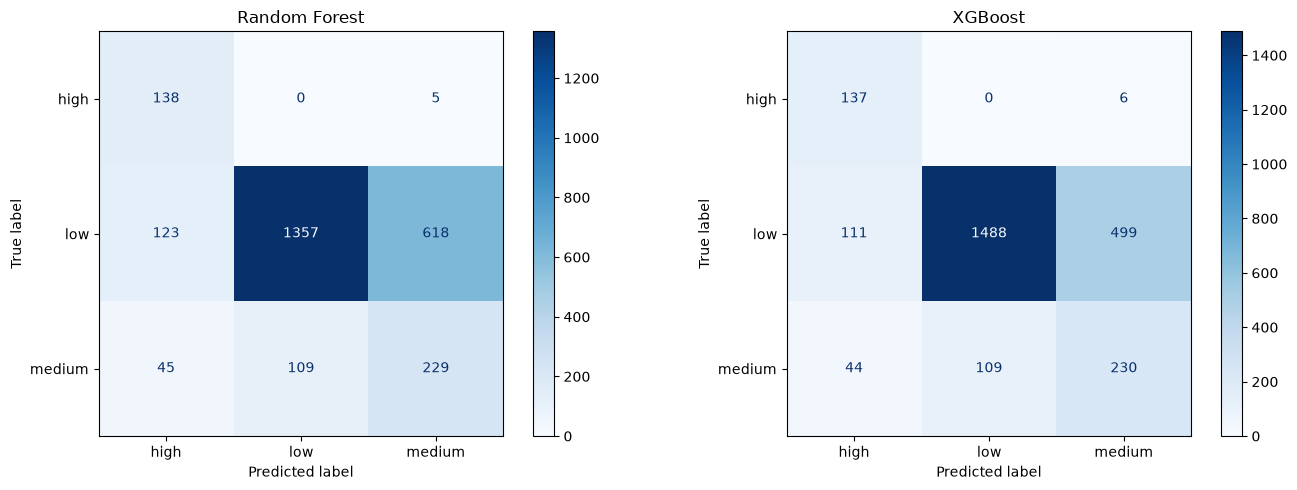

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in [(axes[0], y_pred_rf, 'Random Forest'), (axes[1], y_pred_xgb, 'XGBoost')]:
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, ax=ax, cmap='Blues')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('../docs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance

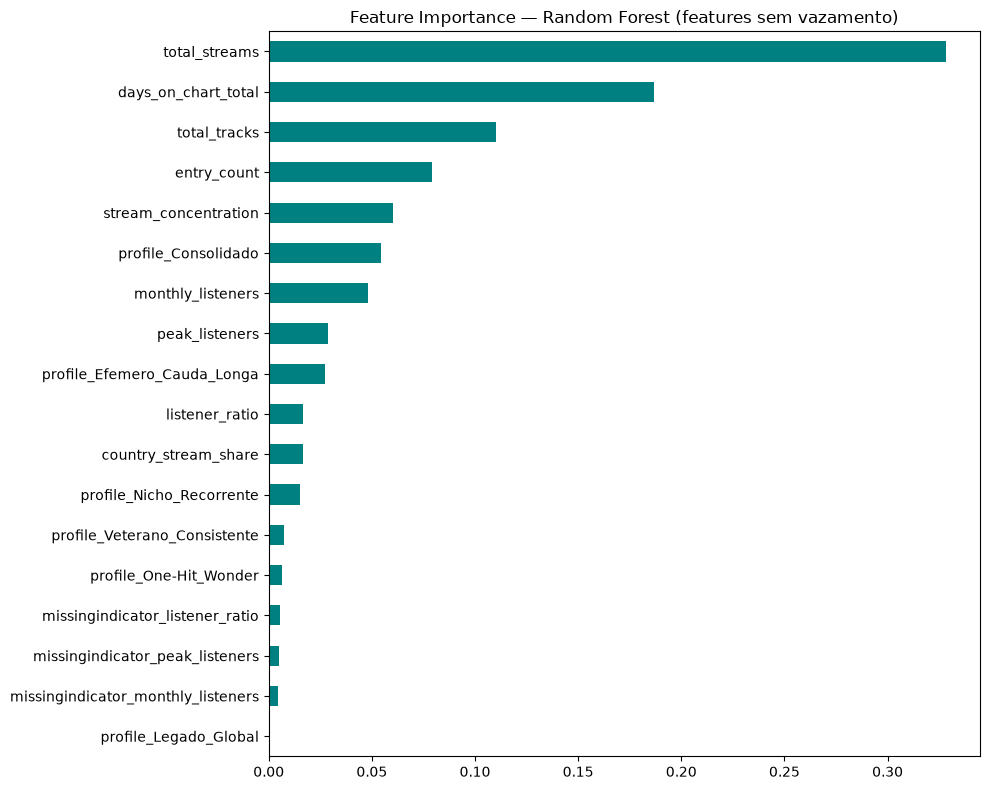

In [20]:
feature_names_out = pipe_rf.named_steps['prep'].get_feature_names_out()
feature_names_out = [f.split('__')[-1] for f in feature_names_out]

importances = pd.Series(
    pipe_rf.named_steps['clf'].feature_importances_, index=feature_names_out
).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
importances.plot.barh(ax=ax, color='teal')
ax.set_title('Feature Importance — Random Forest (features sem vazamento)')
plt.tight_layout()
plt.savefig('../docs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Gerar Score de Recomendação

`recommend_label` é a regra de negócio (ground truth usado para treinar o modelo), **não** é a previsão. `predicted_label` é a classe que o próprio Random Forest prevê. `recommend_score` é a probabilidade da classe `high` segundo o modelo — mede **momentum atual** (ativo + entre os mais tocados do país agora), não "fama histórica". Isso importa para o perfil `Legado Global` (ver notebook 01): uma banda consagrada mas sem chart recente (ex. Guns N' Roses) tem `profile = Legado Global` corretamente, mas `recommend_score` baixo — porque não está "bombando" agora, o que é a pergunta que o score responde. São eixos diferentes por design: `profile` = quem é o artista, `recommend_score` = vale a pena reservar AGORA.

In [21]:
probas = pipe_rf.predict_proba(df_model[feature_cols])
high_idx = list(le.classes_).index('high')
df_model['recommend_score'] = probas[:, high_idx] * 100
df_model['predicted_label'] = le.inverse_transform(pipe_rf.predict(df_model[feature_cols]))

result = df_model[['artist_uri', 'artist_name', 'country', 'profile', 'trend_status',
                    'recommend_label', 'predicted_label', 'recommend_score']]
result.to_csv('../data/processed/model_results.csv', index=False)
print('Scores salvos!')
print('\nTop 15 artistas recomendados — Brasil:')
result[result['country']=='br'].nlargest(15, 'recommend_score')[
    ['artist_name', 'profile', 'trend_status', 'recommend_score', 'recommend_label', 'predicted_label']
]

Scores salvos!

Top 15 artistas recomendados — Brasil:


,artist_name,profile,trend_status,recommend_score,recommend_label,predicted_label
13059,Henrique & Juliano,Veterano Consistente,Em Declinio,97.157222,high,high
6867,Zé Neto & Cristiano,Veterano Consistente,Estavel,96.941554,high,high
4334,Matheus & Kauan,Veterano Consistente,Estavel,96.930847,high,high
13085,Marília Mendonça,Veterano Consistente,Em Ascensao,96.809763,high,high
2774,Jorge & Mateus,Veterano Consistente,Estavel,96.534593,high,high
6199,Murilo Huff,Consolidado,Em Ascensao,95.113463,high,high
12414,Filipe Ret,Veterano Consistente,Em Ascensao,95.050164,high,high
8594,Maiara & Maraisa,Veterano Consistente,Em Ascensao,94.874701,high,high
13072,MC Cabelinho,Veterano Consistente,Em Ascensao,94.717174,high,high
6457,Orochi,Veterano Consistente,Estavel,94.645651,high,high


In [22]:
# A ideia final da tabela: ranquear os artistas dentro de cada perfil, não só no geral.
# Isso só faz sentido porque agora os 6 perfis estao corretamente definidos (ver notebook 01).
country_check = 'br'
top_per_profile = (
    result[result['country'] == country_check]
    .sort_values('recommend_score', ascending=False)
    .groupby('profile')
    .head(3)
    .sort_values(['profile', 'recommend_score'], ascending=[True, False])
)
print(f'Top 3 por perfil — {country_check.upper()}:')
print(top_per_profile[['profile', 'artist_name', 'recommend_score', 'trend_status']].to_string(index=False))

print()
print("Checagem pontual -- Guns N' Roses (banda consagrada, sem chart recente):")
print(result[result['artist_name'].str.contains("Guns N", case=False, na=False)][
    ['artist_name', 'country', 'profile', 'recommend_score', 'trend_status']
].to_string(index=False))

Top 3 por perfil — BR:
             profile         artist_name  recommend_score trend_status
         Consolidado         Murilo Huff        95.113463  Em Ascensao
         Consolidado  Grupo Menos É Mais        94.231551  Em Declinio
         Consolidado Diego & Victor Hugo        93.635358  Em Declinio
 Efemero Cauda Longa       Paulo Vicente         4.509218  Em Ascensao
 Efemero Cauda Longa       Avril Lavigne         1.438126      Inativo
 Efemero Cauda Longa          Audioslave         1.304862      Estavel
       Legado Global          The Police        48.072225  Em Declinio
       Legado Global       Guns N' Roses        20.003759  Em Ascensao
       Legado Global           Lil Wayne         3.375143      Inativo
    Nicho Recorrente     Dj Yuri Pedrada        73.034507  Em Ascensao
    Nicho Recorrente       Danilo e Davi        71.347561      Estavel
    Nicho Recorrente                Nilo        71.191486  Em Declinio
      One-Hit Wonder      Dj Caio Vieira        65.567